In [1]:
!unzip -q "archive (1).zip" -d /content/

# Importing Libraries

In [2]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import random

print("Libraries loaded successfully!")
print("TensorFlow version:", tf.__version__)

Libraries loaded successfully!
TensorFlow version: 2.20.0


# Exploratory Data Analysis

In [3]:
import os

# Updated paths based on the actual folder structure
train_path = "/content/seefood/train"
test_path  = "/content/seefood/test"

# Count train images
hot_dog_count     = len(os.listdir(os.path.join(train_path, "hot_dog")))
not_hot_dog_count = len(os.listdir(os.path.join(train_path, "not_hot_dog")))

print(f"Hot dog images (train):     {hot_dog_count}")
print(f"Not hot dog images (train): {not_hot_dog_count}")

# Count test images
test_hot_dog_count     = len(os.listdir(os.path.join(test_path, "hot_dog")))
test_not_hot_dog_count = len(os.listdir(os.path.join(test_path, "not_hot_dog")))
print(f"Hot dog images (test):      {test_hot_dog_count}")
print(f"Not hot dog images (test):  {test_not_hot_dog_count}")

Hot dog images (train):     249
Not hot dog images (train): 249
Hot dog images (test):      250
Not hot dog images (test):  250


# Visualization

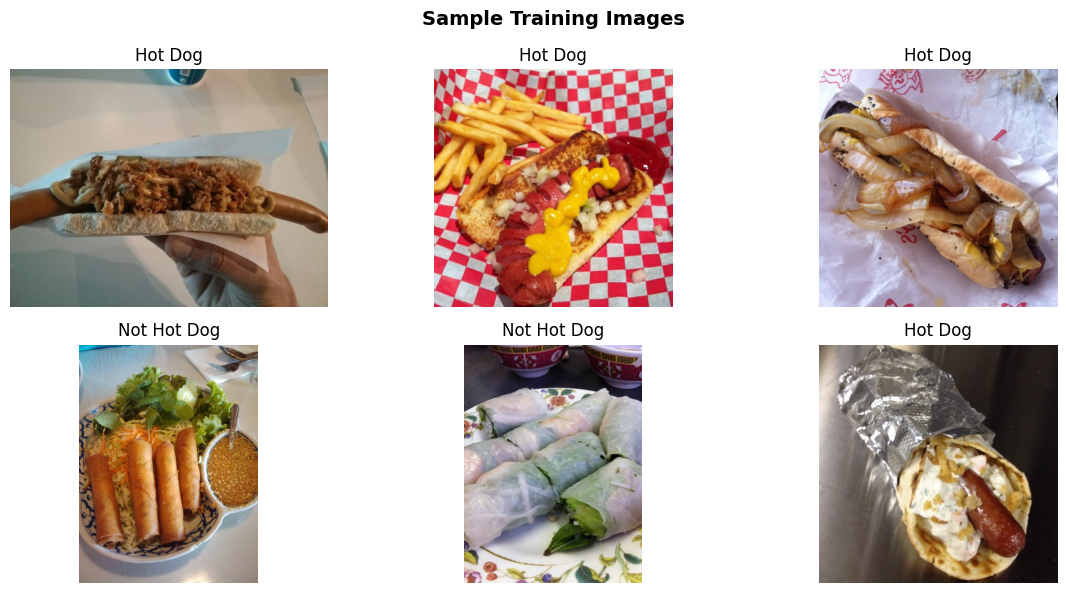

Image shape (height, width, channels): (512, 512, 3)


In [4]:
plt.figure(figsize=(12, 6))
for i in range(6):
    class_name = random.choice(["hot_dog", "not_hot_dog"])
    class_path = os.path.join(train_path, class_name)
    img_name   = random.choice(os.listdir(class_path))
    img_path   = os.path.join(class_path, img_name)

    img = plt.imread(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name.replace("_", " ").title())
    plt.axis('off')

plt.suptitle("Sample Training Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("step4_sample_images.png", dpi=150, bbox_inches='tight')
plt.show()

# Print shape of one image
print("Image shape (height, width, channels):", img.shape)

# Preparing the Data Generators

In [5]:
IMG_HEIGHT = 64
IMG_WIDTH  = 64
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

print("Class indices:", train_generator.class_indices)

Found 400 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Class indices: {'hot_dog': 0, 'not_hot_dog': 1}


# Buildling ANN

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,313 (6.03 MB)

 Trainable params: 1,581,313 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.5125 - loss: 2.4504 - val_accuracy: 0.5000 - val_loss: 0.9648
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.5175 - loss: 0.8629 - val_accuracy: 0.5102 - val_loss: 0.8635
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.6575 - loss: 0.6422 - val_accuracy: 0.5408 - val_loss: 0.8174
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.6075 - loss: 0.6686 - val_accuracy: 0.5306 - val_loss: 0.7221
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.6575 - loss: 0.5855 - val_accuracy: 0.5714 - val_loss: 0.7324
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.7175 - loss: 0.5498 - val_accuracy: 0.5102 - val_loss: 0.8229
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.7050 - loss: 0.5660 - val_accuracy: 0.5102 - val_loss: 0.7542
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.7300 - loss: 0.5502 - val_accuracy: 0.5102 -

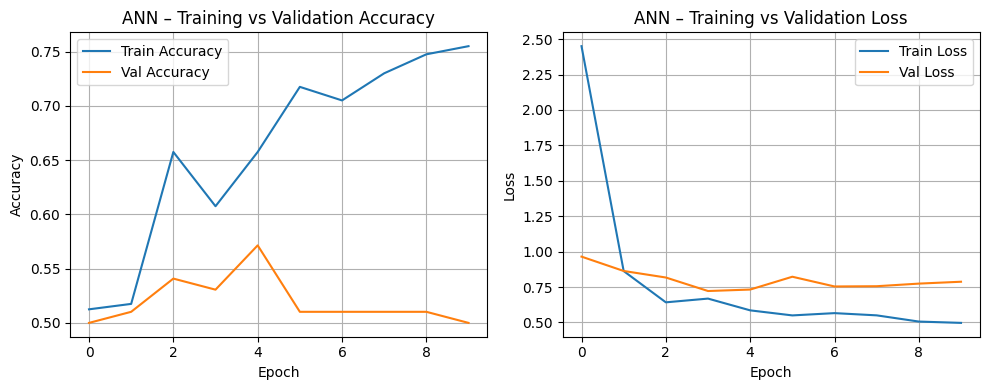

ANN Final Validation Accuracy: 50.0 %


In [6]:
ann_model = keras.Sequential([
    layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(1,   activation='sigmoid')
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

history_ann = ann_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

# Plot ANN training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_ann.history['accuracy'],     label='Train Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('ANN – Training vs Validation Accuracy')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_ann.history['loss'],     label='Train Loss')
plt.plot(history_ann.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('ANN – Training vs Validation Loss')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.savefig("step6_ann_curves.png", dpi=150, bbox_inches='tight')
plt.show()

print("ANN Final Validation Accuracy:",
      round(history_ann.history['val_accuracy'][-1] * 100, 2), "%")

# Building CNN

In [7]:
cnn_model = keras.Sequential([
    # First Conv Block
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second Conv Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Conv Block  ← YOUR TURN (filled in)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classifier Head
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

history_cnn = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

print("CNN Final Validation Accuracy:",
      round(history_cnn.history['val_accuracy'][-1] * 100, 2), "%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,905 (796.50 KB)

 Trainable params: 203,905 (796.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 238ms/step - accuracy: 0.4975 - loss: 0.6975 - val_accuracy: 0.5000 - val_loss: 0.6890
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 248ms/step - accuracy: 0.5250 - loss: 0.6892 - val_accuracy: 0.5408 - val_loss: 0.6884
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 264ms/step - accuracy: 0.6100 - loss: 0.6701 - val_accuracy: 0.6020 - val_loss: 0.6776
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step - accuracy: 0.5775 - loss: 0.6599 - val_accuracy: 0.5612 - val_loss: 0.6740
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.6725 - loss: 0.6132 - val_accuracy: 0.6020 - val_loss: 0.6748
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step - accuracy: 0.7125 - loss: 0.5765 - val_accuracy: 0.6327 - val_loss: 0.6857
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 313ms/step - accuracy: 0.7450 - loss: 0.5422 - val_accuracy: 0.6122 - val_loss: 0.6740
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 217ms/step - accuracy: 0.7550 - loss: 0.4968 - val_accuracy: 0.

## Comparison Plots

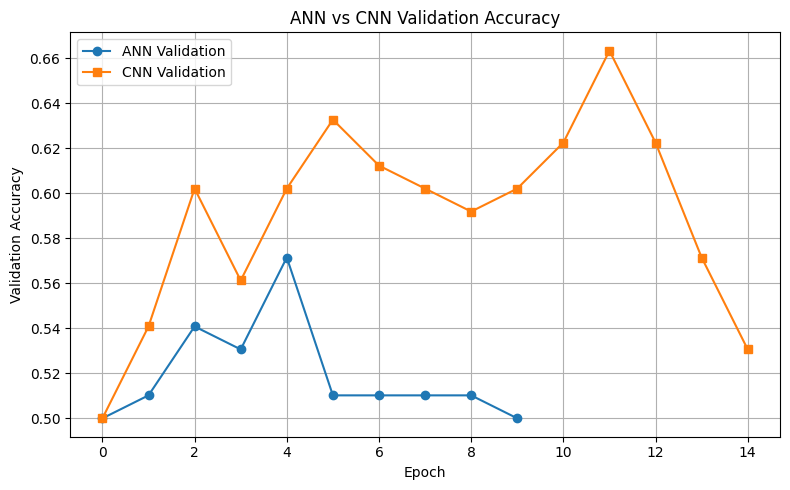

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(history_ann.history['val_accuracy'], label='ANN Validation', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation', marker='s')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.legend(); plt.title('ANN vs CNN Validation Accuracy')
plt.grid(True)
plt.tight_layout()
plt.savefig("step7_ann_vs_cnn.png", dpi=150, bbox_inches='tight')
plt.show()

# Dropout

In [9]:
from tensorflow.keras import regularizers

improved_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),                          # Fix 1

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),                          # Fix 2

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),                           # Fix 3
    layers.Dense(1, activation='sigmoid')
])

improved_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_improved = improved_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 250ms/step - accuracy: 0.5200 - loss: 0.7066 - val_accuracy: 0.5000 - val_loss: 0.6917
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 0.5025 - loss: 0.6969 - val_accuracy: 0.4898 - val_loss: 0.6920
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 307ms/step - accuracy: 0.4875 - loss: 0.6959 - val_accuracy: 0.5000 - val_loss: 0.6913
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step - accuracy: 0.5300 - loss: 0.6888 - val_accuracy: 0.5408 - val_loss: 0.6911
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 217ms/step - accuracy: 0.5325 - loss: 0.6908 - val_accuracy: 0.5714 - val_loss: 0.6902
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step - accuracy: 0.5825 - loss: 0.6838 - val_accuracy: 0.5918 - val_loss: 0.6845
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 337ms/step - accuracy: 0.5550 - loss: 0.6794 - val_accuracy: 0.5306 - val_loss: 0.6839
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step - accuracy: 0.5925 - loss: 0.6680 - val_accuracy: 0.

# Dropout + Data Augmentation

In [10]:
augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_augmented = augmented_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

final_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

final_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_final = final_model.fit(
    train_augmented,
    validation_data=validation_generator,
    epochs=15
)

print("Final Model Validation Accuracy:",
      round(history_final.history['val_accuracy'][-1] * 100, 2), "%")

Found 400 images belonging to 2 classes.
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 275ms/step - accuracy: 0.5425 - loss: 0.6962 - val_accuracy: 0.5000 - val_loss: 0.6951
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 341ms/step - accuracy: 0.5200 - loss: 0.7056 - val_accuracy: 0.5000 - val_loss: 0.6922
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 253ms/step - accuracy: 0.5025 - loss: 0.7001 - val_accuracy: 0.5510 - val_loss: 0.6925
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 248ms/step - accuracy: 0.4950 - loss: 0.6926 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 283ms/step - accuracy: 0.5025 - loss: 0.6958 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 310ms/step - accuracy: 0.5275 - loss: 0.6929 - val_accuracy: 0.5612 - val_loss: 0.6930
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 250ms/step - accuracy: 0.5375 - loss: 0.6928 - val_accuracy: 0.5714 - val_loss: 0.6924
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 251ms/step - accuracy:

# Before vs After Overfitting Fix Plot

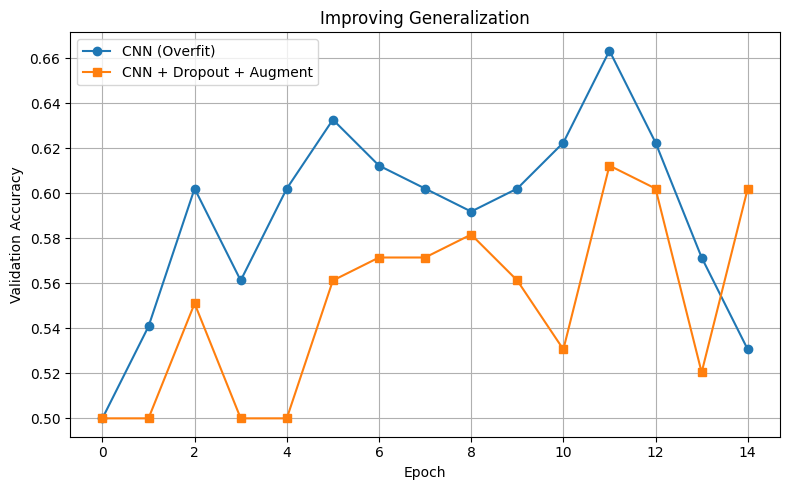

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history['val_accuracy'],
         label='CNN (Overfit)', marker='o')
plt.plot(history_final.history['val_accuracy'],
         label='CNN + Dropout + Augment', marker='s')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.legend(); plt.title('Improving Generalization')
plt.grid(True)
plt.tight_layout()
plt.savefig("step8_overfitting_fix.png", dpi=150, bbox_inches='tight')
plt.show()

# Test on Real Images

In [12]:
from tensorflow.keras.preprocessing import image
import os

def predict_local_image(img_path="real_image.png"):
    if not os.path.exists(img_path):
        print(f"Error: '{img_path}' not found. Please upload an image with that name to the /content/ folder.")
        return

    img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = final_model.predict(img_array)[0][0]
    if prediction > 0.5:
        label = f"NOT A HOT DOG (confidence: {prediction:.2f})"
    else:
        label = f"HOT DOG!      (confidence: {1 - prediction:.2f})"

    print(label)
    plt.imshow(img)
    plt.title(label, fontsize=11)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Prediction on real image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
HOT DOG!      (confidence: 0.54)


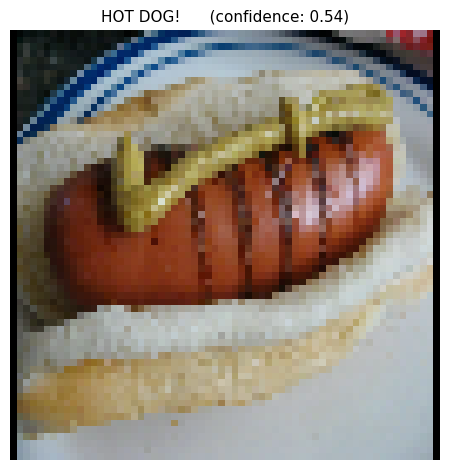

In [15]:
# Simply upload a file named 'real_image.png' to the sidebar then run this:
predict_local_image("HotDog?.png")

# YOLO BONUS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Testing YOLO on: /content/seefood/test/hot_dog/760045.jpg

image 1/1 /content/seefood/test/hot_dog/760045.jpg: 640x480 3 hot dogs, 1 dining table, 376.0ms
Speed: 19.3ms preprocess, 376.0ms inference, 53.3ms postprocess per image at shape (1, 3, 640, 480)


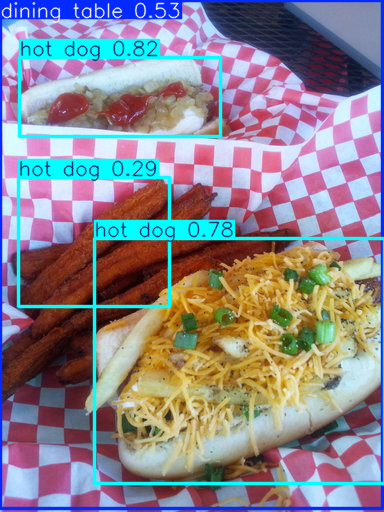

In [14]:
!pip install ultralytics -q
from ultralytics import YOLO
import random
import os

# Initialize the model
yolo_model = YOLO("yolov8n.pt")

# Dynamically grab a random hot dog image from your test folder
test_hot_dog_dir = os.path.join(test_path, "hot_dog")
random_image = random.choice(os.listdir(test_hot_dog_dir))
image_to_test = os.path.join(test_hot_dog_dir, random_image)

print(f"Testing YOLO on: {image_to_test}")

# Run inference
results = yolo_model(image_to_test)

# Display results
results[0].show()